# Objectives
Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
1. Diabetes Classification (Y/N)
2. Feature importance and explainability
3. Early diabetes risk prediction
4. Clustering for risk group 


# Libraries and dependencies

In [61]:
pip install -r requirements.txt

   ---------------------------------------- 0.0/238.4 kB ? eta -:--:--
   ------ -------------------------------- 41.0/238.4 kB 991.0 kB/s eta 0:00:01
   ---------------------------------------- 238.4/238.4 kB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN



# Load dataset

In [38]:
# Define the path correctly
dataset_path = "data/diabetes.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(dataset_path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [39]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [41]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [42]:
# Distribution of the 2 classes in Outcome column
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

In [43]:
# List of continuous numerical columns
X = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

In [44]:
def plot_histograms(df, columns, title='Histograms for Numerical Columns'):
    """
    Plots histograms for the specified numerical columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): List of numerical column names to plot.
        title (str): Title for the entire figure.
    """
    num_cols = len(columns)
    n_rows = (num_cols // 3) + (num_cols % 3 > 0)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=16)
    
    axes = axes.flatten()
    
    for i, column in enumerate(columns):
        axes[i].hist(df[column].dropna(), bins=30, edgecolor='black')
        axes[i].set_title(column)
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
    
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


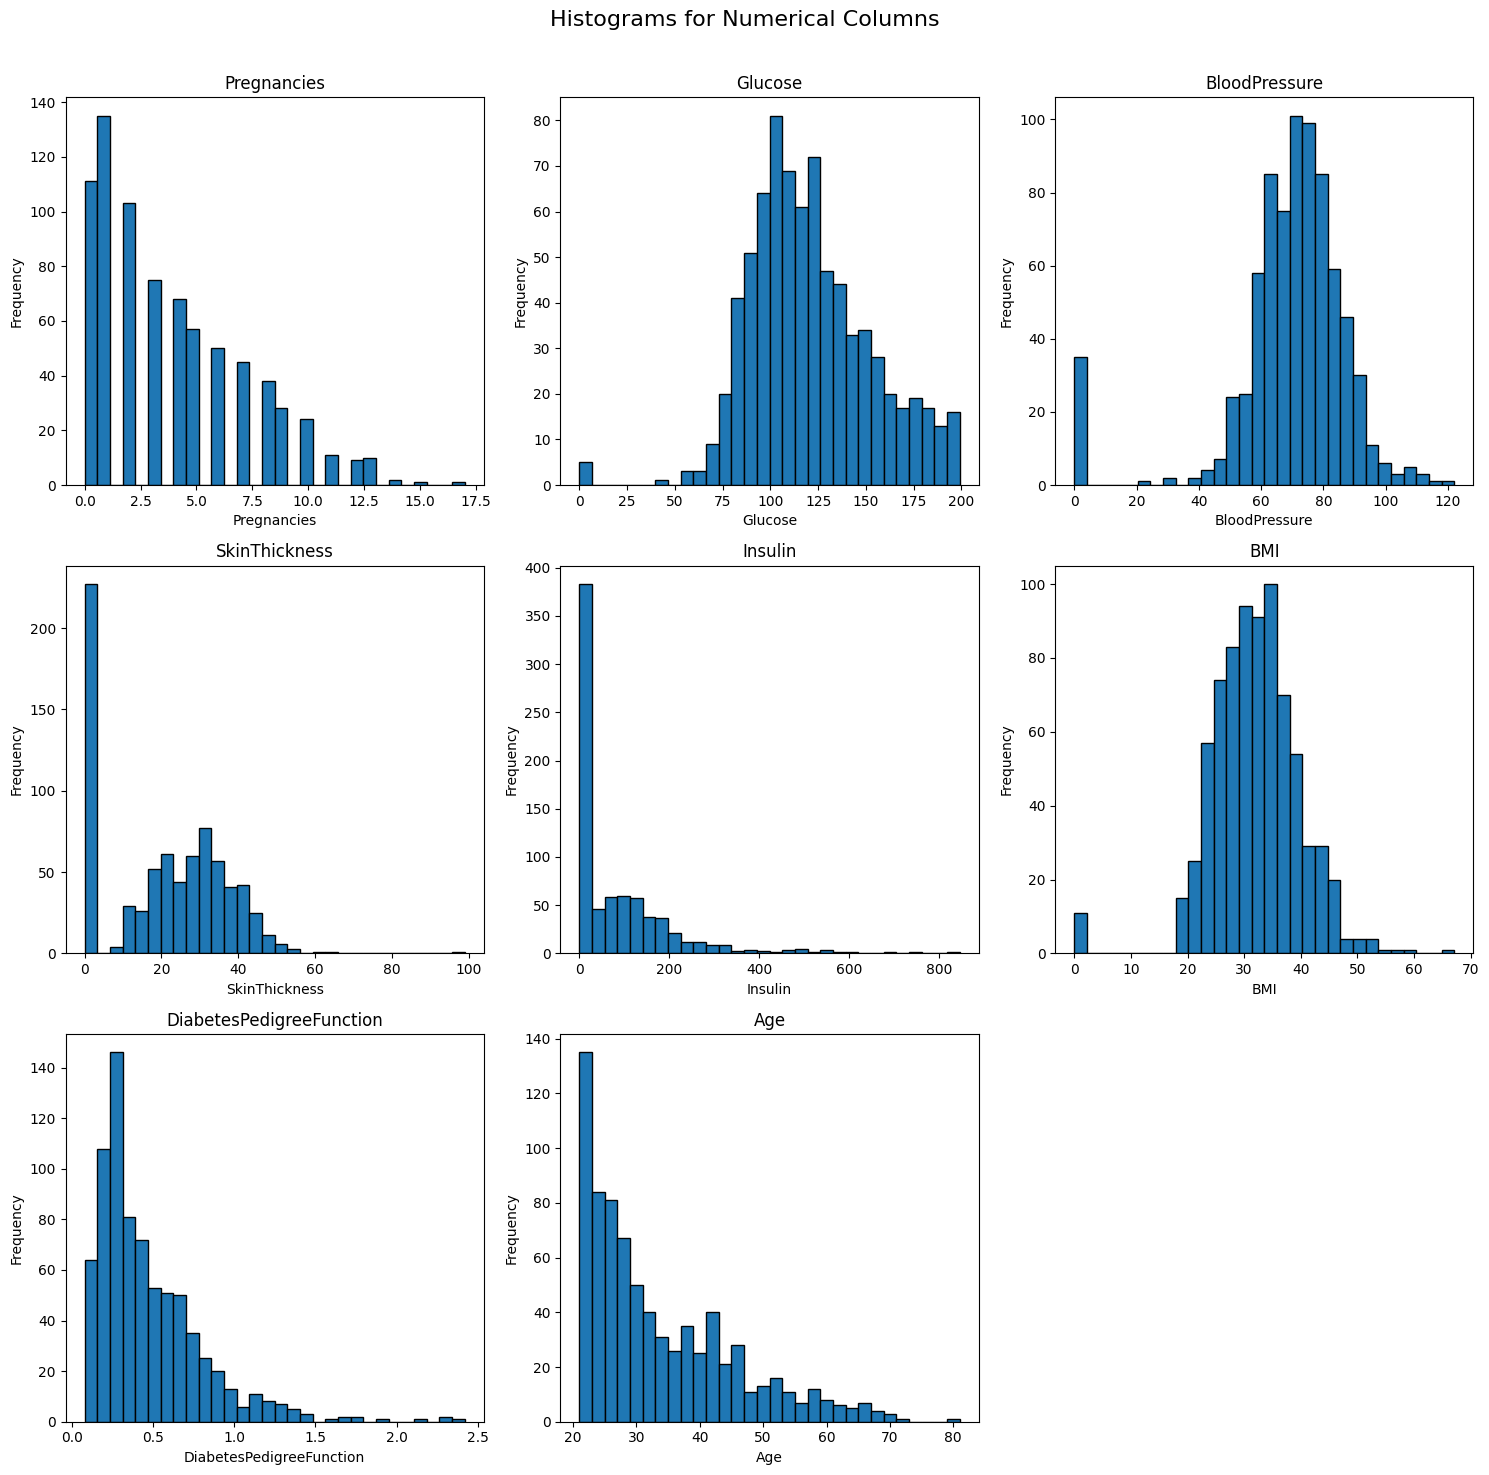

In [45]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Replace 0 in appropriate columns with mean

In [46]:
# List of columns where 0 is invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Impute with mean
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].mean())


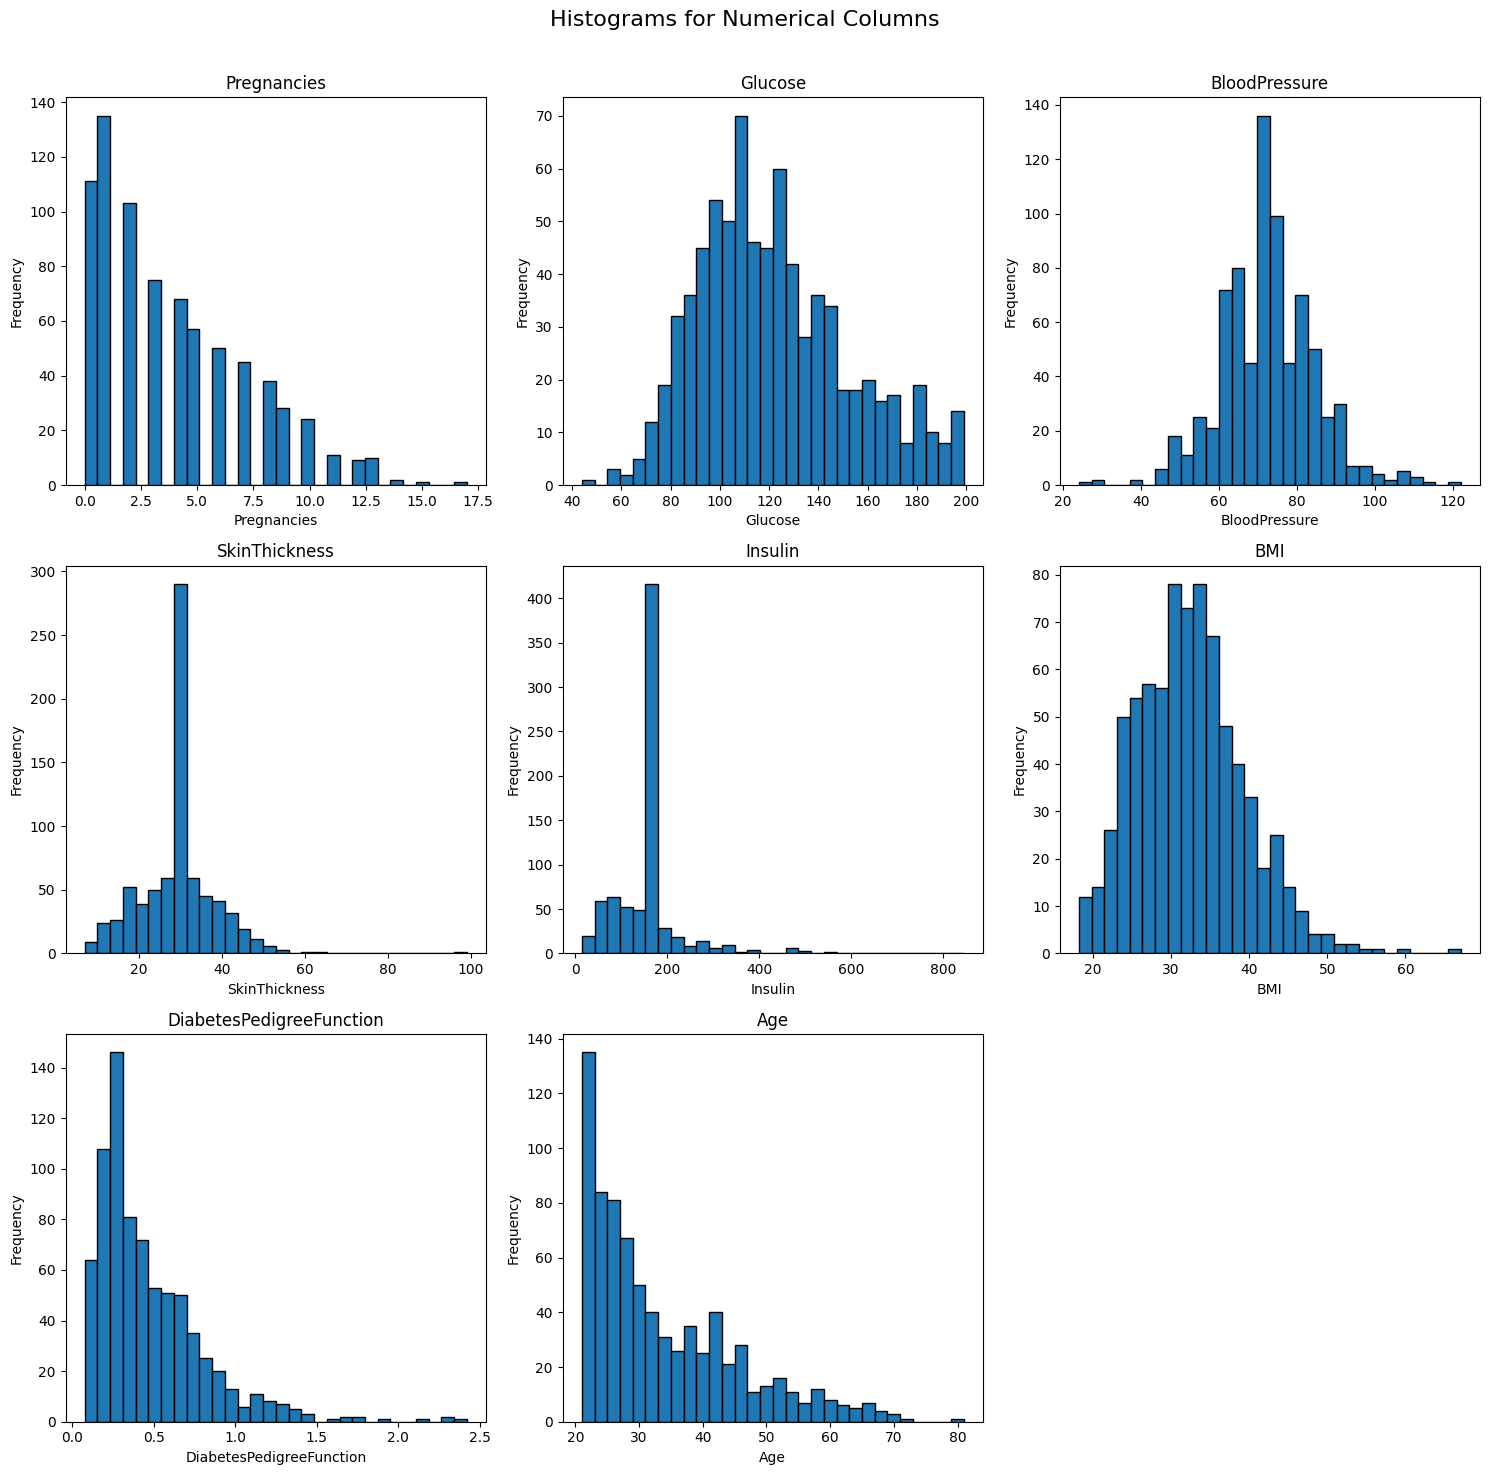

In [47]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Remove outliers z-score>3

In [48]:
# Compute Z-scores only for the selected X columns
z_scores = np.abs(zscore(df[X]))

# Create a mask where all Z-scores are less than or equal to 3 across all X columns
mask = (z_scores <= 3).all(axis=1)

# Apply the mask to filter the DataFrame
df_no_outliers = df[mask].reset_index(drop=True)

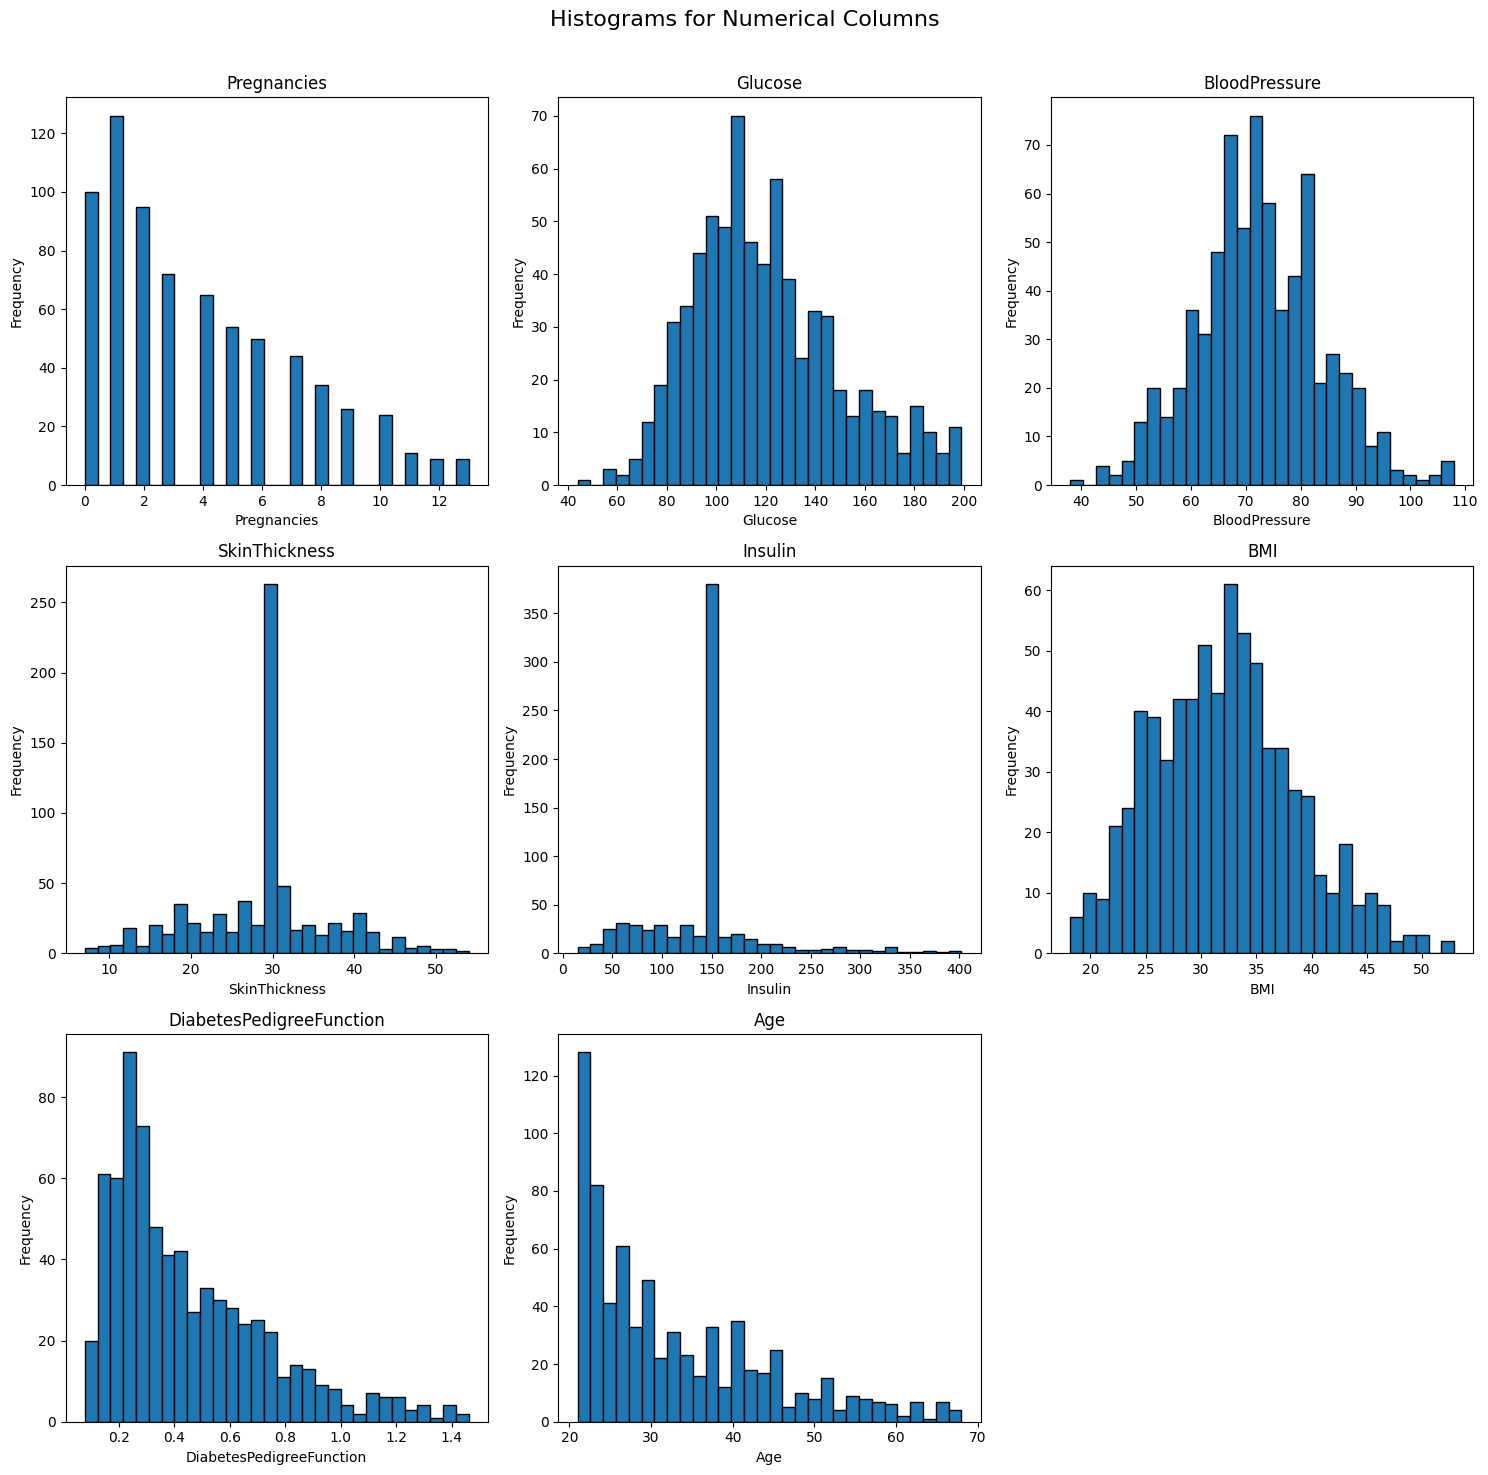

In [49]:
plot_histograms(df_no_outliers, X, title='Histograms for Numerical Columns')

# Min-max scale

In [55]:
# Create a copy of the DataFrame to keep original safe
df_minmax_scaled = df_no_outliers.copy()

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the X columns
df_minmax_scaled[X] = scaler.fit_transform(df_minmax_scaled[X])


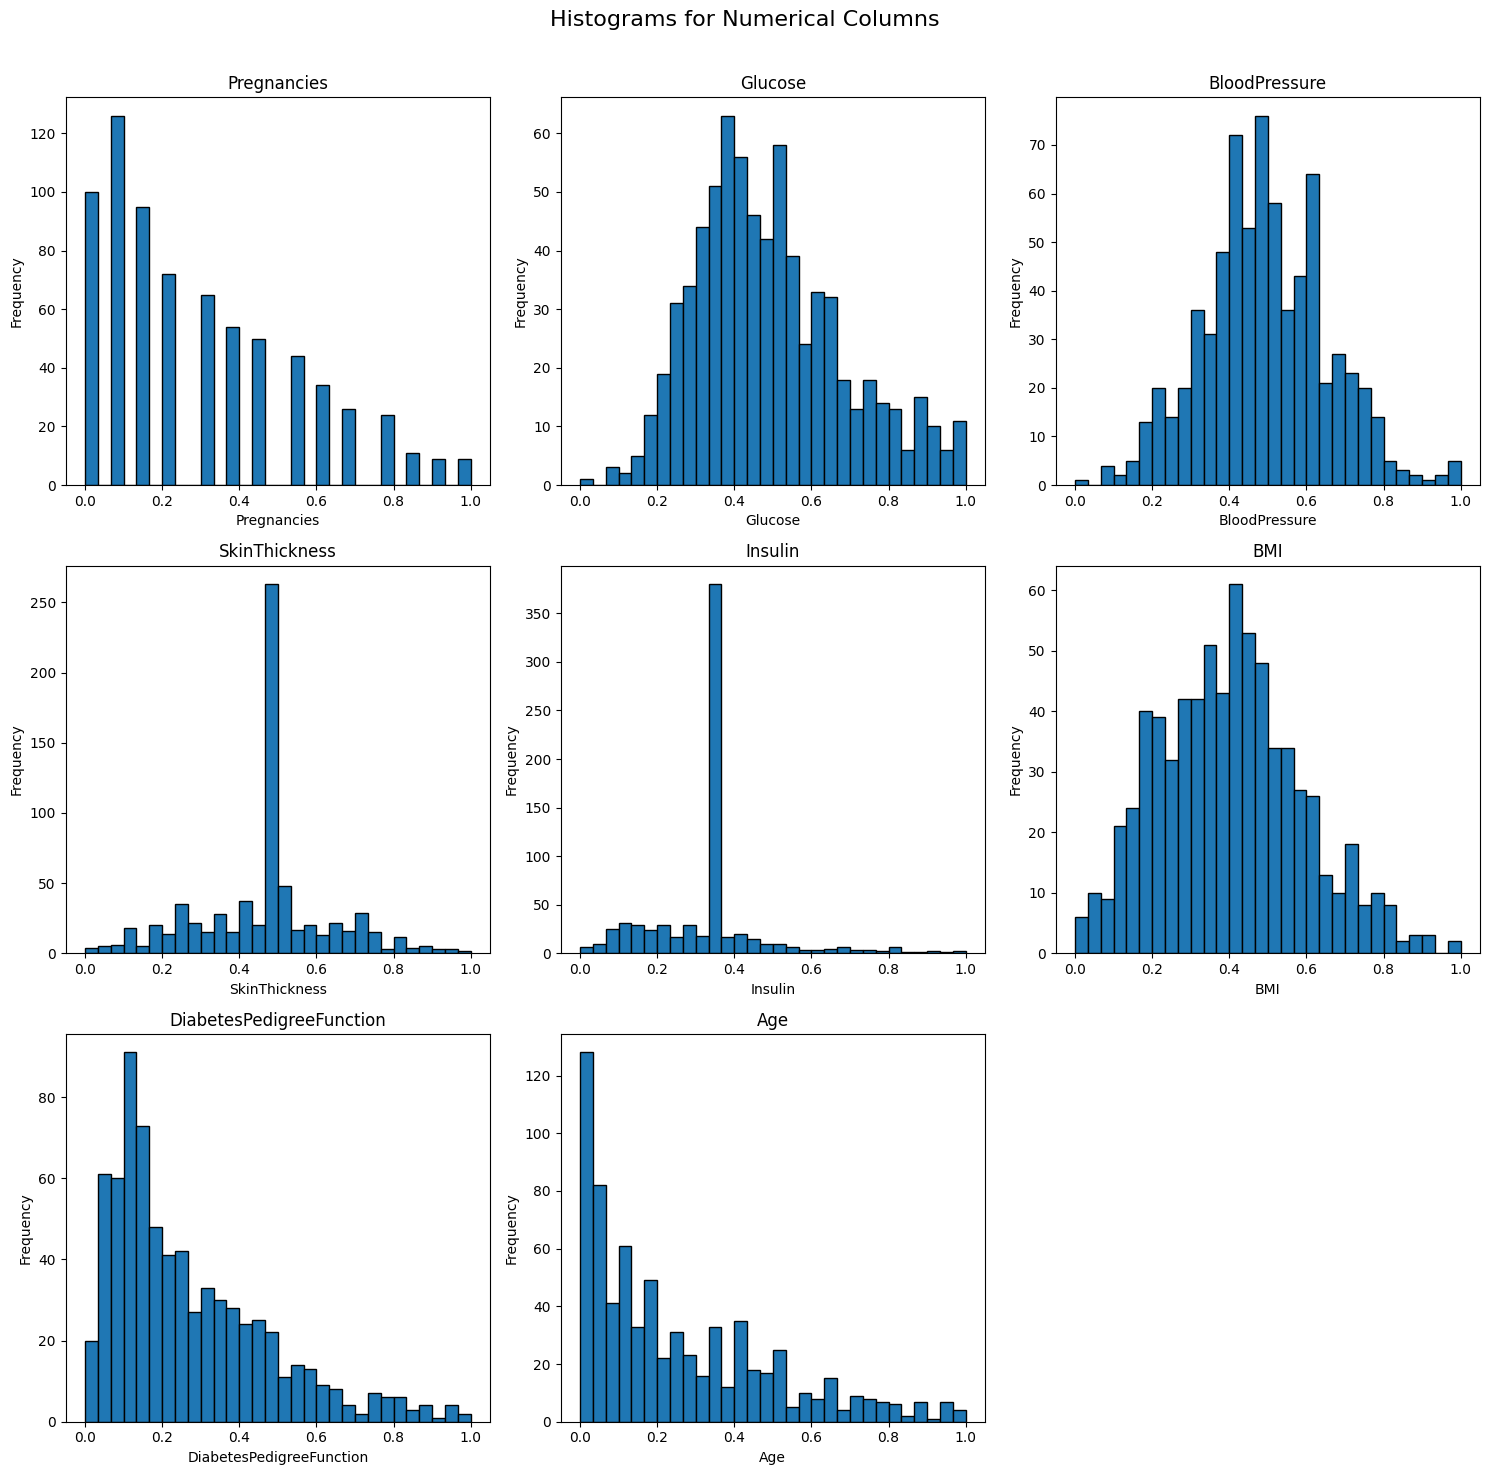

In [57]:
plot_histograms(df_minmax_scaled, X, title='Histograms for Numerical Columns')

# Standard scale

In [58]:
# Create a copy to keep the original safe
df_standard_scaled = df_no_outliers.copy()

# Choose columns to scale with StandardScaler
standard_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']  # all X columns

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
df_standard_scaled[standard_cols] = scaler.fit_transform(df_standard_scaled[standard_cols])

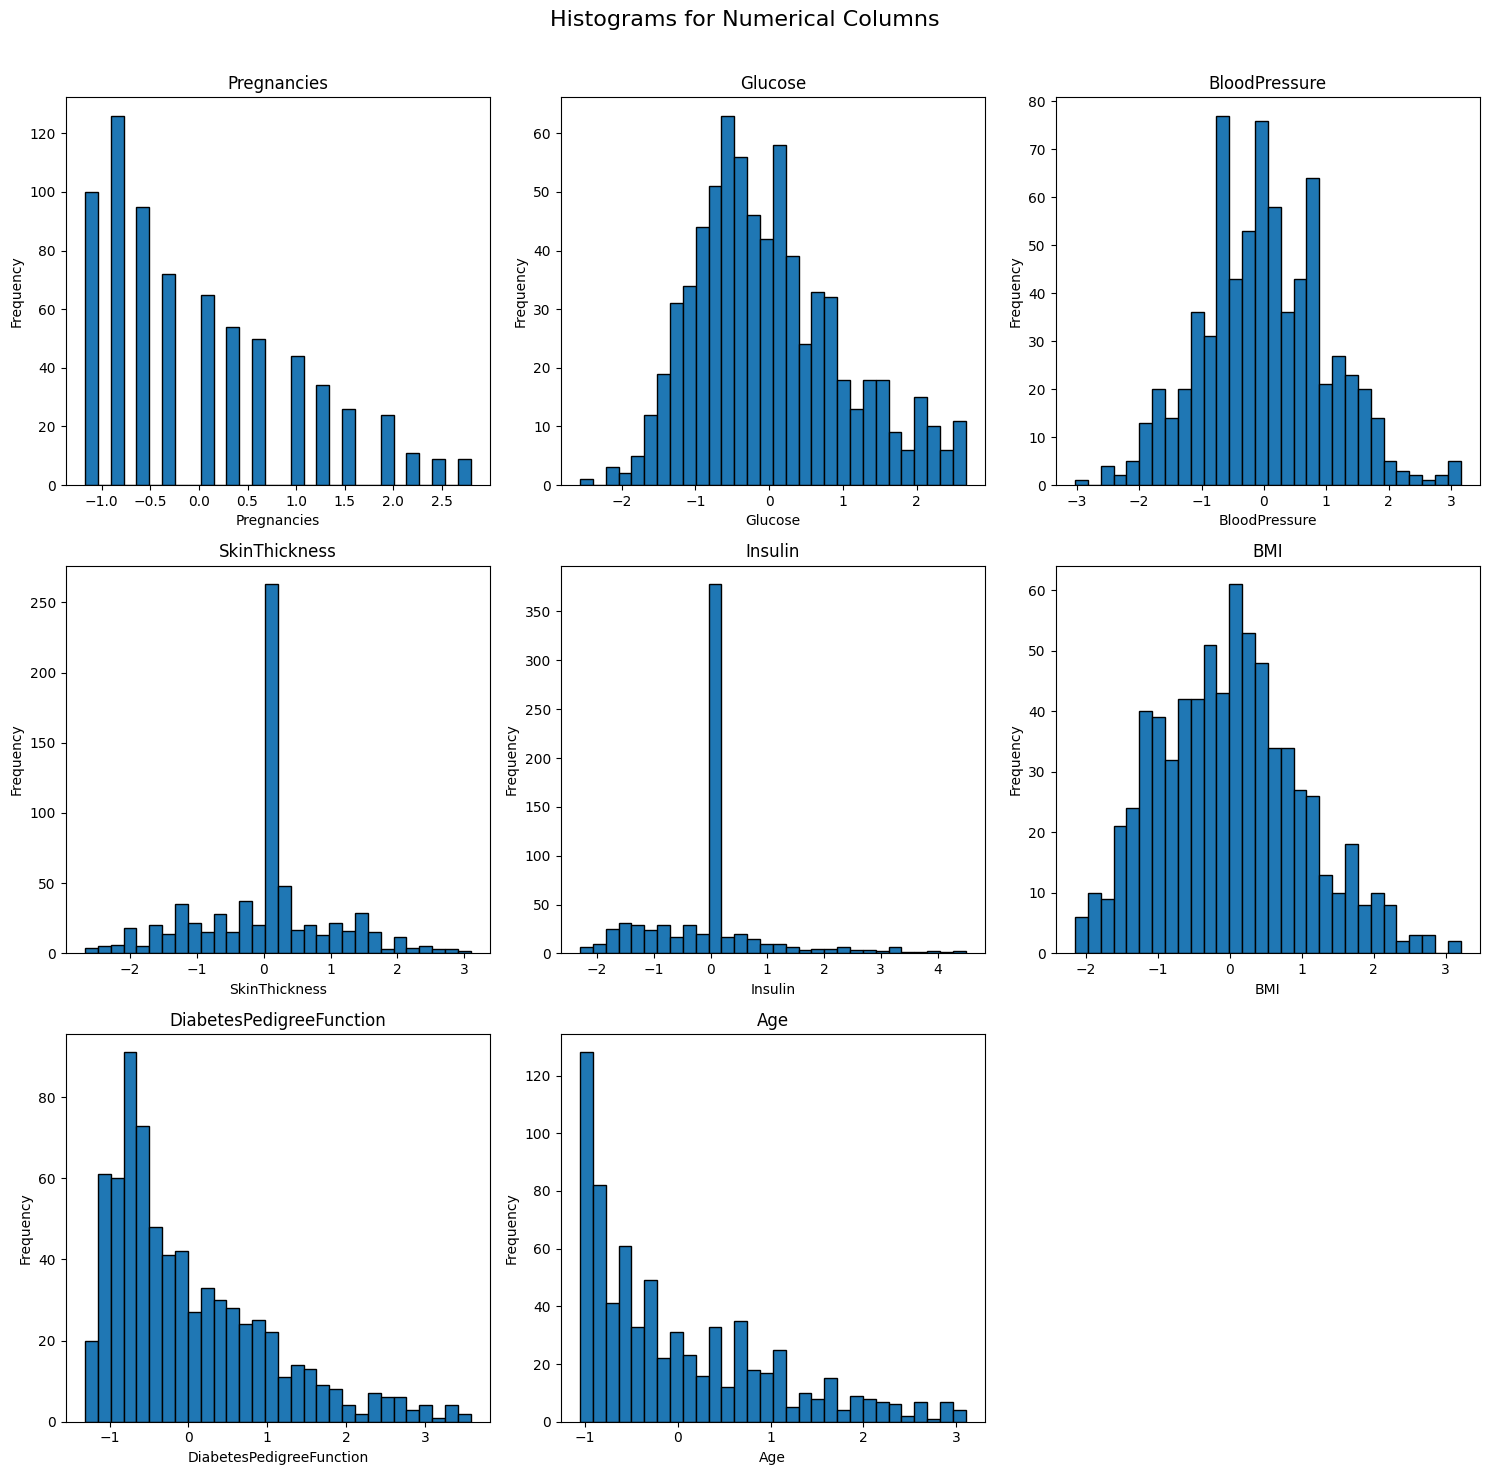

In [59]:
plot_histograms(df_standard_scaled, X, title='Histograms for Numerical Columns')

# Mix of scalers - respective to each column's distribution

# SMOTE - to handle class imbalance

In [64]:


# 1. Separate features and target
X = df_standard_scaled.drop(columns='Outcome')   # assuming 'Outcome' is your label
y = df_standard_scaled['Outcome']

# 2. Train-test split (stratify helps maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Now you can train your model on X_train_sm, y_train_sm


In [65]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())


Before SMOTE: Outcome
0    381
1    194
Name: count, dtype: int64
After SMOTE: Outcome
0    381
1    381
Name: count, dtype: int64


# ADASYN - to hanndle class imbalance

In [66]:
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

In [67]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_adasyn.value_counts())


Before SMOTE: Outcome
0    381
1    194
Name: count, dtype: int64
After SMOTE: Outcome
0    381
1    350
Name: count, dtype: int64


# Feature engineering